# Optimization Result Visualization

This notebook visualizes the files produced by `PSO-ConstitutiveParaOptimization.ipynb`. `Error.csv` stores one normalized stress-curve deviation per DAMASK simulation. `Stress_strain.csv` stores the experimental curve in the first two columns and every simulated curve after that as `epsilon_N` / `sigma_N` column pairs.


## 1. Error of Every Simulation



317


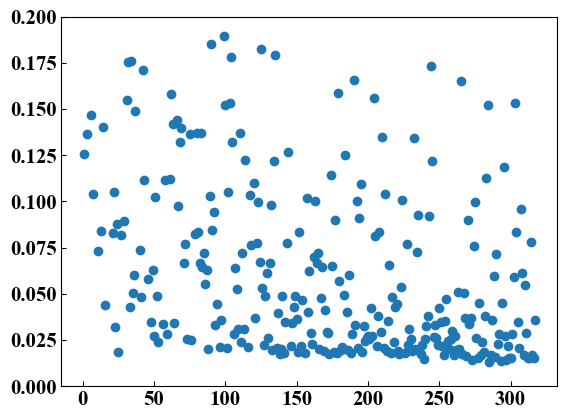

In [20]:
# Plot the error value recorded for every individual DAMASK simulation.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Error.csv is written by PSO-ConstitutiveParaOptimization.ipynb. Each row after
# the header corresponds to one parameter set / one DAMASK simulation.
err = pd.read_csv('Error.csv', usecols=['error'])
err = np.asarray(err).squeeze()
err = err[~np.isnan(err)]

# Use the simulation number as the x-axis. If n_particles = 20 in the PSO notebook,
# then every 20 points correspond to one full PSO iteration.
num = err.size
x = np.linspace(1, num, num)
print(num)

plt.ylim(0, 0.2)
plt.plot(x, err, 'o')


## 2. Best Error per PSO Iteration

Group errors by PSO population size and plot the minimum deviation reached in each iteration.


16


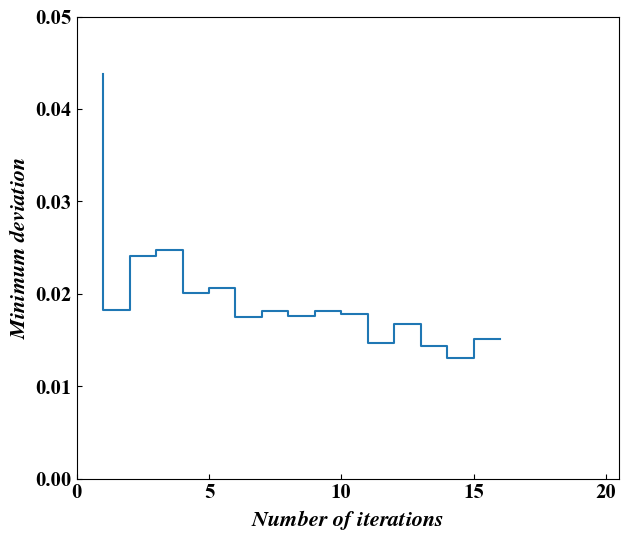

In [21]:
# -----------------------------------------------------------------------------
# Plot the best error achieved in each PSO iteration.
# -----------------------------------------------------------------------------
def find_min_every_20(lst):
    # The PSO notebook uses n_particles = 20, so each chunk of 20 errors belongs
    # to one optimizer iteration. The minimum in each chunk is the iteration best.
    min_values = []
    for i in range(0, len(lst), 20):
        chunk = lst[i:i+20]
        min_value = min(chunk)
        min_values.append(min_value)
    return min_values

# err is the complete error history loaded in the previous cell.
your_list = err

min_values = find_min_every_20(your_list)
num_err = len(min_values)
x = np.linspace(1, num_err, num_err)
print(num_err)

# Configure a publication-style figure for the convergence curve.
figsize = 7, 6
fig, ax = plt.subplots(figsize=figsize)
config = {
    'mathtext.fontset': 'stix',
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 15,
    'axes.unicode_minus': False,
    'font.weight': 'bold',
    'axes.labelweight': 'bold'
}
plt.rcParams.update(config)

label_prop = {'family': 'Arial', 'size': 16}
# ax.set_title('Yield loci')

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.ylim(0, 0.05)
plt.xlim(0, 20.5)

# A step plot makes the iteration-to-iteration improvement easy to see.
plt.step(x, min_values, '-')
plt.xlabel(r'$Number\ of\ iterations$', fontsize=16)
plt.ylabel(r'$Minimum\ deviation$', fontsize=16)
plt.savefig('Error.png', dpi=300)


## 3. Best Simulated Curve

Find the simulation with the smallest error and compare its stress-strain response with the experimental curve.


285
0.0130601498266246


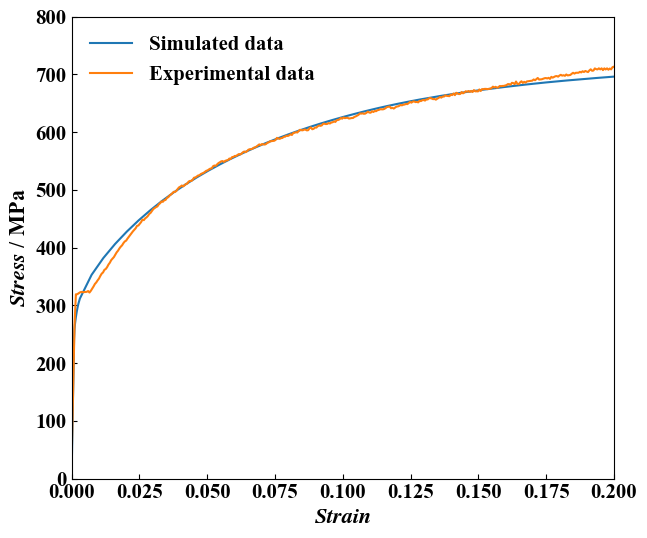

In [22]:
# -----------------------------------------------------------------------------
# Plot the simulated stress-strain curve with the minimum error.
# -----------------------------------------------------------------------------
figsize = 7, 6
fig, ax = plt.subplots(figsize=figsize)

plt.ylim(0, 800)
plt.xlim(0, 0.2)

# Load the full error history and find the best simulation. np.argmin returns a
# zero-based index, while the Stress_strain.csv columns are named from 1, so the
# curve column number is min_index + 1.
err = pd.read_csv('Error.csv', usecols=['error'])
err = np.asarray(err).squeeze()
err = err[~np.isnan(err)]
min_value = np.min(err)
min_index = np.argmin(err)

# Read the best simulated curve. DAMASK stress is stored in Pa, so divide by 1e6
# before plotting against the experimental curve in MPa.
epsilon = pd.read_csv('Stress_strain.csv', usecols=([f'epsilon_{min_index+1}']))
sigma = pd.read_csv('Stress_strain.csv', usecols=([f'sigma_{min_index+1}']))
ax.plot(epsilon, sigma / 1000000, label='Simulated data')

# The experimental curve is always stored in the first two columns.
epsilon = pd.read_csv('Stress_strain.csv', usecols=['Strain'])
sigma = pd.read_csv('Stress_strain.csv', usecols=['Stress'])
ax.plot(epsilon, sigma, label='Experimental data')

plt.legend(loc=0, facecolor='white', edgecolor='white')
plt.xlabel(r'$Strain$', fontsize=16)
plt.ylabel(r'$Stress$ / MPa', fontsize=16)

# Print the best simulation number and its normalized L2 error.
print(min_index + 1)
print(min_value)
plt.savefig('Iterations.png', dpi=300)
